In [8]:
# Mesh independence study
import pybamm
import numpy as np


no_cycles = 1
# Stadardised Formation Cycling Bham group
# exp = pybamm.Experiment( [("Charge at C/20 until 4.2 V",
#                            "Hold at 4.2 V for 1 hours", 
#                            "Hold at 4.2 V until 2.5 mA", 
#                            "Discharge at C/20 until 2.5 V",
#                            "Charge at C/20 until 3.8 V",
#                            "Hold at 3.8 V for 1 hours"
#                            )]* no_cycles)


exp = pybamm.Experiment(
    [("Charge at C/20 until 4.2 V",
      "Rest for 5 hours",
      "Discharge at C/20 until 2.5 V",
      "Rest for 5 hours",
      )]* no_cycles )
params=[]
for i in range(1, 5):
    param=pybamm.ParameterValues("Chen2020")
    param.update({"Negative particle radius [m]": 5.86e-06*1,
                  "Positive particle radius [m]": 5.22e-06*1})
    params.append(param)

models = [pybamm.lithium_ion.SPM(), 
          pybamm.lithium_ion.SPM(), 
          pybamm.lithium_ion.SPM(),
          pybamm.lithium_ion.SPM()]
models_names = ["DFN", "SPMe", "SPM", "RM"]

var_pts = [ {
    "x_n": 10,  # negative electrode
    "x_s": 10,  # separator
    "x_p": 10,  # positive electrode
    "r_n": 20//index,  # negative particle
    "r_p": 20//index,  # positive particle
} for index in range(1, 5)]



solver = pybamm.CasadiSolver(mode="safe")
sims = [pybamm.Simulation(model, parameter_values=params[index], var_pts=var_pts[index], experiment=exp, solver=solver) for index, model in enumerate(models)]
sols = [sim.solve(initial_soc=0) for sim in sims]

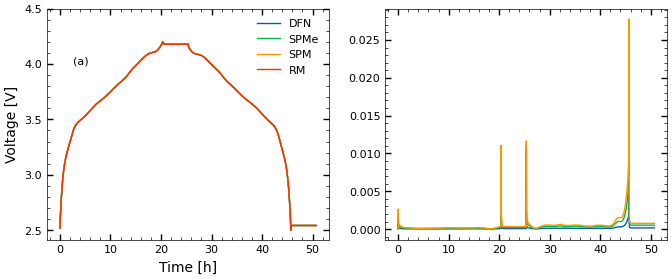

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scienceplots
import matplotlib.ticker as ticker
import numpy as np

from style_figs import set_plotting_format

set_plotting_format("paper")  # input should be either "presentation" or "paper"

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharex=True)


# First subplot
for index, model_name in enumerate(models_names[:4]):
    time = sols[index]["Time [h]"].entries
    voltage = sols[index]["Terminal voltage [V]"].entries
    axes[0].plot(time, voltage, label=model_name)

axes[0].legend()  # Increased legend font size
axes[0].set_xlabel("Time [h]")
axes[0].set_ylabel("Voltage [V]")
axes[0].text(2.5, 4.0, "(a)")

# Set x-axis ticks and labels for the first subplot using a loop
xticks = np.arange(0, 70, 10)
axes[0].set_xticks(xticks)
axes[0].set_xticklabels(xticks)

# Set y-axis ticks for the first subplot using a loop
yticks = np.arange(2.5, 5, 0.5)
axes[0].set_yticks(yticks)

# Second subplot
t_max = max(sol["Time [s]"].entries[-1] for sol in sols)
t = np.linspace(0, t_max, 100000)

for index in range(1, 4):
    error = sols[0]["Terminal voltage [V]"](t) - sols[index]["Terminal voltage [V]"](t)
    axes[1].plot(t / 3600, np.abs(error), label=f"{models_names[0]} - {models_names[index]}")

# axes[1].legend()  # Increased legend font size
# axes[1].set_xlabel("Time [h]")
# axes[1].set_ylabel("Log$_{10}$ [V]")
# axes[1].text(5, 1e-1, "(b)")

# # Set x-axis ticks and labels for the second subplot using a loop
# axes[1].set_xticks(xticks)
# axes[1].set_xticklabels(xticks)

# # Adjusting the number of ticks on the y-axis for the second subplot
# axes[1].yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=4))  # Use LogLocator for y-axis

# plt.tight_layout()
# plt.savefig("figures/fig1.png", dpi=300)